# 1. Online Retail Sales Analysis using Python

## Project Overview

This project analyzes online retail transaction data to understand sales performance, identify best-selling products, and examine customer purchasing behaviour. The goal is to generate actionable business insights that support inventory management, marketing strategies, and customer retention.

## Objectives

- Clean and prepare the dataset.
- Analyze sales performance.
- Identify best-selling products.
- Analyze customer behaviour.
- Provide business recommendations.

# Table of Contents

1. Introduction
2. Import Libraries
3. Load Dataset
4. Data Understanding
5. Data Cleaning
6. Feature Engineering
7. Sales Performance Analysis
8. Best-Selling Products
9. Customer Analysis
10. Key Findings
11. Business Recommendations

In [28]:
# 2. Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [5]:
# 3. Load Dataset
from google.colab import files

uploaded = files.upload()

df = pd.read_excel("Online Retail.xlsx")
df.head()

Saving Online Retail.xlsx to Online Retail.xlsx


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
# 4. Data Understanding
# Before cleaning the dataset, we first explore its structure, data types, missing values, and summary statistics to understand its overall quality and identify potential data issues.

## 4.1 Display First 5 Rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Observation

The dataset contains transaction-level records. Each row represents a purchased product within an invoice, including product details, quantity, price, customer ID, and country.

In [ ]:
# 4.2 Dataset Shape
print(df.shape)

### Observation

The dataset contains **541,909 rows** and **8 columns**, indicating a large transactional dataset suitable for retail sales analysis.

In [ ]:
# 4.3 Data Types
df.info()

### Observation

The dataset contains a mixture of numerical, categorical, and datetime variables. CustomerID is stored as a numeric value, while InvoiceDate will be converted to datetime for time-based analysis.

In [ ]:
# 4.4 Summary Statistics
df.describe()

### Observation

The summary statistics reveal the distribution of numerical variables such as Quantity and UnitPrice. Negative quantities indicate returned or cancelled transactions, while zero-priced items may represent invalid records or promotional items.

In [7]:
# 4.5 Missing Values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


### Observation

The Description and CustomerID columns contain missing values. Missing CustomerID records cannot be linked to individual customers and will be removed before customer analysis.

In [10]:
# 5. Data Cleaning

# Remove duplicates
df = df.drop_duplicates()

# Remove missing descriptions
df = df.dropna(subset=["Description"])

# Remove missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove cancelled invoices
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove negative quantities
df = df[df["Quantity"] > 0]

# Remove zero prices
df = df[df["UnitPrice"] > 0]

# Check dataset again
df.shape

(392692, 8)

In [11]:
# 6. Feature Engineering

# Create Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Convert date
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Extract Month
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

In [12]:
# 7. Sales Performance Analysis
#This section provides an overview of the business's sales performance through key performance indicators (KPIs) and monthly revenue trends. The analysis helps identify overall business performance and sales patterns over time.

## Total Revenue
total_revenue = df["Revenue"].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

## Number of Orders
total_orders = df["InvoiceNo"].nunique()

print(f"Total Orders: {total_orders:,}")

## Total Customers
total_customers = df["CustomerID"].nunique()

print(f"Total Customers: {total_customers:,}")

## Average Order Value
order_revenue = df.groupby("InvoiceNo")["Revenue"].sum()

average_order = order_revenue.mean()

print(f"Average Order Value: £{average_order:.2f}")

Total Revenue: £8,887,208.89
Total Orders: 18,532
Total Customers: 4,338
Average Order Value: £479.56


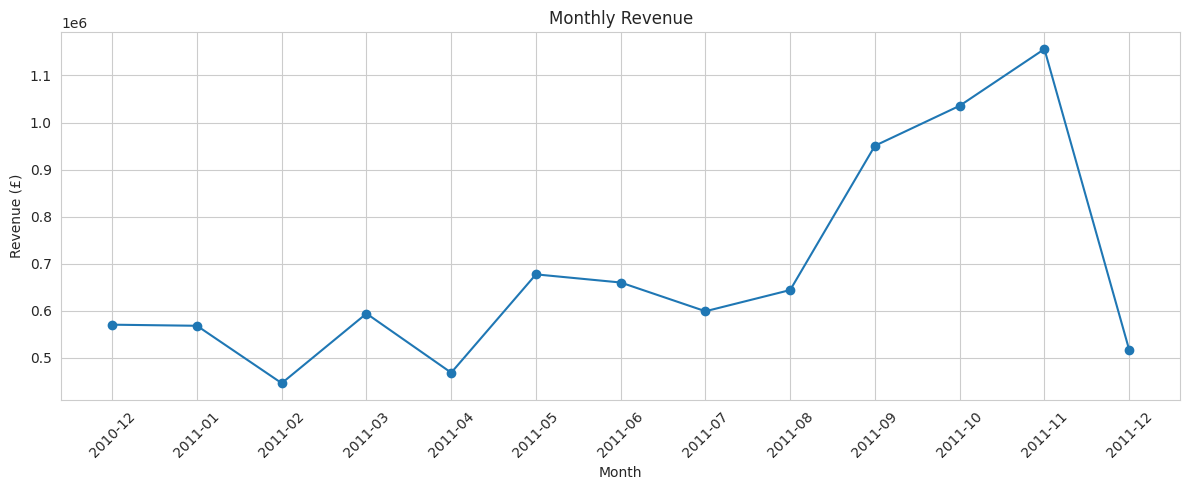

In [13]:
# Monthly Sales Trend
monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,5))

plt.plot(monthly_sales["Month"],
         monthly_sales["Revenue"],
         marker="o")

plt.xticks(rotation=45)

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue (£)")

plt.tight_layout()

plt.show()

### Insights
*   Revenue generally increased toward the end of the year.

*   The highest revenue occurred during the holiday shopping season.

*   Some months had noticeably lower sales, suggesting periods where targeted promotions could help maintain revenue.


### Business Recommendations

- Increase inventory levels and marketing efforts before peak sales periods to meet higher customer demand.
- Monitor monthly sales trends regularly to identify seasonal patterns and improve sales forecasting.
- Focus promotional campaigns during slower months to maintain more consistent revenue throughout the year.
- Track key performance indicators (KPIs) such as revenue, order volume, and average order value to evaluate business performance and support data-driven decision-making.

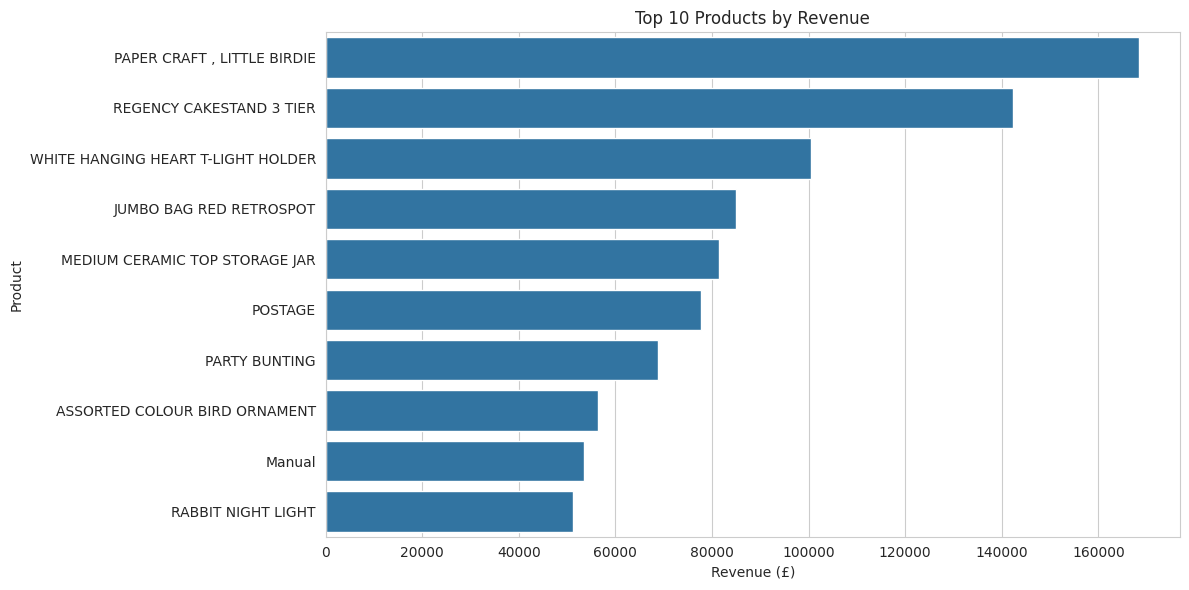

In [14]:
# 8. Best-Selling Products
# This section identifies the products that contribute the most to sales by analyzing both revenue and quantity sold.
# These insights help businesses prioritize inventory, marketing, and product strategy.

## Top 10 Products by Revenue
product_summary = (
    df.groupby("Description")
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Number_of_Orders=("InvoiceNo", "nunique")
      )
      .reset_index()
)

top_revenue = (
    product_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

top_revenue

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_revenue,
    x="Total_Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Insights

*   The top 10 products contribute a significant share of total revenue.
*   These products should receive priority in inventory management and promotional campaigns.
*   Maintaining stock availability for these products may help maximize revenue.


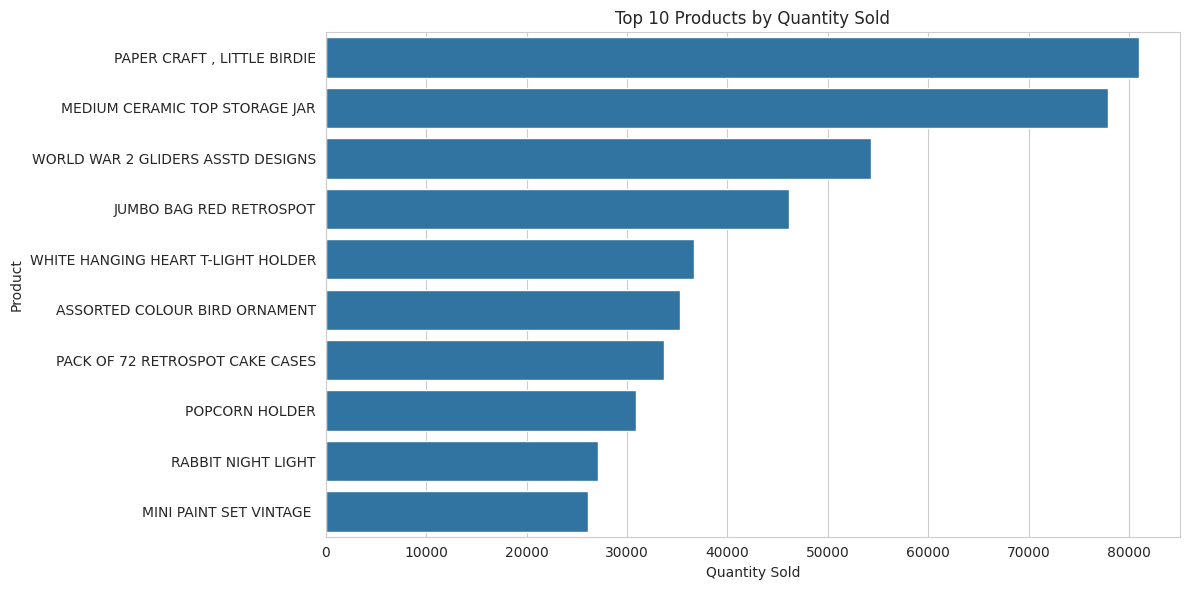

In [15]:
## Top 10 Products by Sold Quantity

top_quantity = (
    product_summary
    .sort_values("Total_Quantity", ascending=False)
    .head(10)
)

top_quantity

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_quantity,
    x="Total_Quantity",
    y="Description"
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Insights

*   These products are purchased most frequently by customers.
*   High sales volume may indicate consistent customer demand.


*   Ensuring sufficient stock levels for these products can reduce the risk of stockouts.





In [16]:
## Revenue vs Quantity
comparison = (
    product_summary[
        ["Description", "Total_Revenue", "Total_Quantity"]
    ]
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

comparison

,Description,Total_Revenue,Total_Quantity
2319,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
2767,REGENCY CAKESTAND 3 TIER,142264.75,12374
3698,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706
1762,JUMBO BAG RED RETROSPOT,85040.54,46078
1992,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916
2611,POSTAGE,77803.96,3120
2345,PARTY BUNTING,68785.23,15279
216,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263
2130,Manual,53419.93,6933
2656,RABBIT NIGHT LIGHT,51251.24,27153


In [17]:
## Products Performance Matrix

revenue_threshold = product_summary["Total_Revenue"].quantile(0.90)
quantity_threshold = product_summary["Total_Quantity"].quantile(0.90)

def classify_product(row):
    if row["Total_Revenue"] >= revenue_threshold and row["Total_Quantity"] >= quantity_threshold:
        return "Star Product"
    elif row["Total_Revenue"] >= revenue_threshold and row["Total_Quantity"] < quantity_threshold:
        return "Premium Product"
    elif row["Total_Revenue"] < revenue_threshold and row["Total_Quantity"] >= quantity_threshold:
        return "Volume Product"
    else:
        return "Low Performer"

product_summary["Category"] = product_summary.apply(classify_product, axis=1)

import plotly.express as px

fig = px.scatter(
    product_summary,
    x="Total_Quantity",
    y="Total_Revenue",
    color="Category",
    hover_name="Description",
    hover_data={
        "Total_Revenue": ":,.2f",
        "Total_Quantity": ":,",
        "Category": True
    },
    title="Product Performance Matrix (Revenue vs Quantity Sold)",
    labels={
        "Total_Quantity": "Quantity Sold",
        "Total_Revenue": "Revenue (£)"
    }
)

fig.add_vline(
    x=quantity_threshold,
    line_dash="dash",
    line_color="black"
)

fig.add_hline(
    y=revenue_threshold,
    line_dash="dash",
    line_color="black"
)

fig.update_traces(
    marker=dict(size=8),
    opacity=0.6
)

fig.show()

fig.write_html("product_performance_matrix.html")

from google.colab import files
files.download("product_performance_matrix.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Insights

- Most products are classified as **Low Performers**, indicating that a large proportion of the product catalogue generates relatively low sales volume and revenue.
- A small number of **Star Products** achieve both high sales volume and high revenue, making them key contributors to overall business performance.
- **Premium Products** generate high revenue despite lower sales volumes, suggesting they are higher-priced or higher-value items.
- **Volume Products** sell in large quantities but generate comparatively lower revenue, presenting opportunities to increase profitability through pricing strategies or product bundling.

### Business Recommendations

- Prioritize inventory replenishment for Star Products and other high-performing products to reduce the risk of stock shortages and maintain customer satisfaction.
- Feature best-selling products in marketing campaigns and promotional materials to increase visibility and drive additional sales.
- Review pricing and bundling strategies for Volume Products to improve profitability while maintaining strong sales volume.
- Continue promoting Premium Products through targeted marketing campaigns to increase their sales volume without compromising their high revenue contribution.
- Regularly evaluate Low Performing products to determine whether they should be improved, discounted, or discontinued based on customer demand and business objectives.

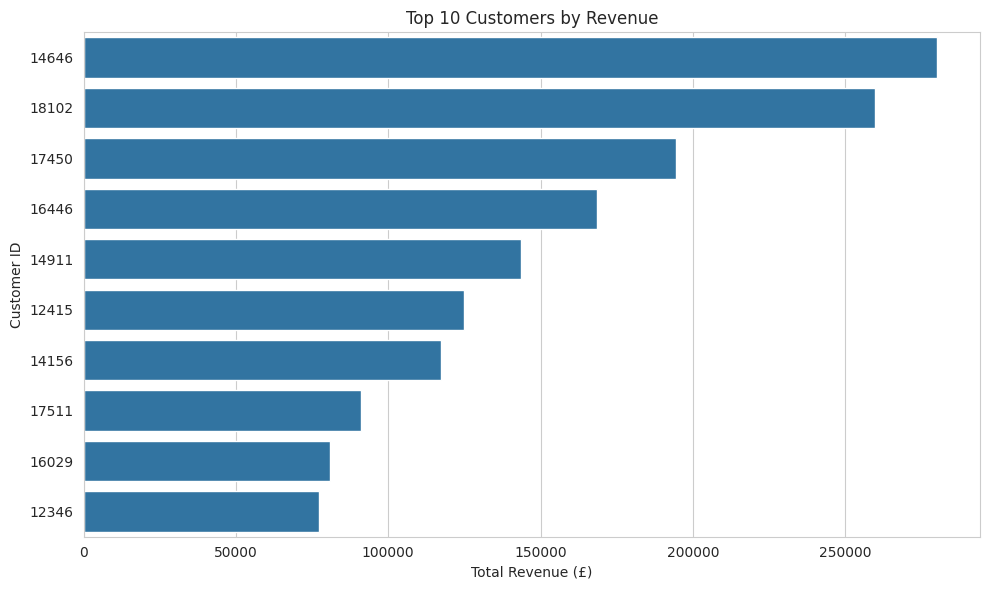

In [31]:
# 9. Customer Analysis
# This section analyzes customer purchasing behavior to identify high-value customers, spending patterns, and repeat purchasing. These insights can help businesses improve customer retention and marketing strategies.

## Customer Summary Table
order_summary = (
    df.groupby(["CustomerID", "InvoiceNo"])
      .agg(
          Order_Value=("Revenue", "sum")
      )
      .reset_index()
)

customer_summary = (
    order_summary.groupby("CustomerID")
    .agg(
        Total_Revenue=("Order_Value", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Average_Order_Value=("Order_Value", "mean")
    )
    .reset_index()
)

customer_items = (
    df.groupby("CustomerID")["Quantity"]
      .sum()
      .reset_index(name="Total_Items")
)

customer_summary = customer_summary.merge(
    customer_items,
    on="CustomerID"
)

## Top 10 Customers by Revenue
top_customers = (
    customer_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers,
    x="Total_Revenue",
    y=top_customers["CustomerID"].astype(int).astype(str),
    orient="h"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

### Insights

- A small group of customers contributes a disproportionately large share of the total revenue, indicating that the business relies heavily on high-value customers.
- The gap in revenue between the highest-spending customers and the remaining customers suggests significant differences in purchasing behaviour.
- Retaining these top customers is important, as losing even a few of them could have a noticeable impact on overall sales.

In [43]:
## Repeat Customers
repeat_customers = customer_summary[
    customer_summary["Total_Orders"] > 1
]

repeat_rate = (
    len(repeat_customers)
    / len(customer_summary)
) * 100

print(f"Repeat Customer Rate: {repeat_rate:.2f}%")
print(f"Total Customers: {len(customer_summary)}")
print(f"Repeat Customers: {len(repeat_customers)}")

Repeat Customer Rate: 65.58%
Total Customers: 4338
Repeat Customers: 2845


### Insights

- A substantial proportion of customers have made more than one purchase, indicating a healthy level of customer retention.
- Repeat customers are likely to contribute more revenue over time compared to one-time buyers.
- Encouraging existing customers to make additional purchases can be more cost-effective than acquiring new customers.

In [44]:
## Customer Revenue vs Number of Orders
import plotly.express as px

fig = px.scatter(
    customer_summary,
    x="Total_Orders",
    y="Total_Revenue",
    hover_data=["CustomerID"],
    title="Customer Revenue vs Number of Orders"
)

fig.show()

### Insights

- Most customers place relatively few orders and generate lower revenue, while a small number of customers contribute significantly higher revenue.
- The positive relationship between the number of orders and total revenue suggests that customers who purchase more frequently generally spend more overall.
- Several high-revenue customers stand out as valuable customer segments that should be prioritised for retention.

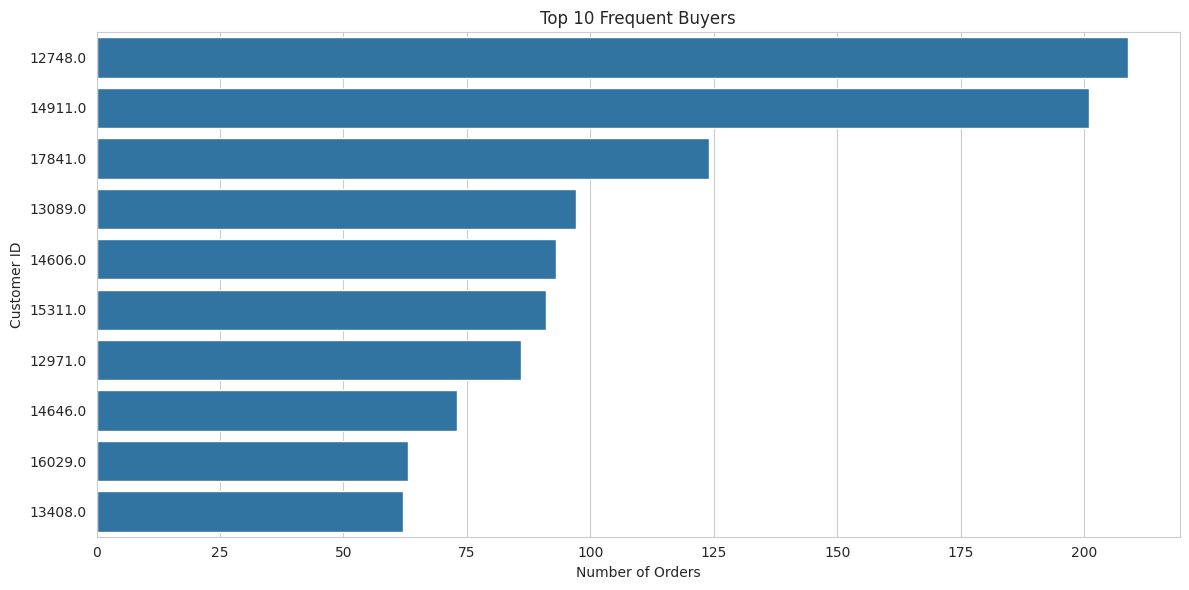

In [52]:
## Top 10 Frequent Buyers
frequent_threshold = customer_summary["Total_Orders"].quantile(0.90)

frequent_buyers = customer_summary[
    customer_summary["Total_Orders"] >= frequent_threshold
].copy()

frequent_buyers = frequent_buyers.sort_values(
    "Total_Orders",
    ascending=False
)

top_frequent = frequent_buyers.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_frequent,
    x="Total_Orders",
    y=top_frequent["CustomerID"].astype(str)
)

plt.title("Top 10 Frequent Buyers")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

### Insights

- Frequent buyers consistently place a large number of orders, demonstrating strong customer loyalty.
- High purchase frequency indicates continued engagement with the business and provides opportunities for cross-selling and upselling.
- Not all frequent buyers necessarily generate the highest revenue, suggesting that purchasing frequency and spending value should both be considered when developing customer strategies.

### Business Recommendations

- Strengthen customer retention by implementing loyalty programmes, personalised promotions, and exclusive rewards for high-value customers.
- Identify potential VIP customers based on their purchasing behaviour and develop targeted marketing campaigns to encourage long-term engagement.
- Encourage repeat purchases through personalised product recommendations, follow-up promotions, and customer retention initiatives.
- Apply cross-selling and upselling strategies to increase the average order value, particularly among frequent buyers and loyal customers.
- Continuously monitor customer purchasing patterns and retention metrics to support data-driven marketing strategies and improve customer lifetime value.